<a href="https://colab.research.google.com/github/NineNattaya/229352-StatisticalLearning/blob/main/Lab10_CNNs_660510737.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Statistical Learning for Data Science 2 (229352)
#### Instructor: Donlapark Ponnoprat

#### [Course website](https://donlapark.pages.dev/229352/)

## Lab #10

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import torchvision # For utils.make_grid
import matplotlib.pyplot as plt
import numpy as np
import os
import zipfile
from PIL import Image
from tqdm.auto import tqdm # For nice progress bars
from sklearn.metrics import accuracy_score

# Set device to GPU if available, else CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


We will use a dataset of pizza, stead and sushi images ([source](https://www.learnpytorch.io/04_pytorch_custom_datasets/))

In [ ]:
!unzip -q pizza_steak_sushi.zip

In [ ]:
train_dir = "train"
test_dir = "test"

# Data augmentation

![augmentation](https://miro.medium.com/max/700/0*LR1ZQucYW96prDte)

See more transformations in [Pytorch documentation](https://docs.pytorch.org/vision/stable/transforms.html#v2-api-reference-recommended)

Class names: ['pizza', 'steak', 'sushi']
Class to index mapping: {'pizza': 0, 'steak': 1, 'sushi': 2}
Number of training samples: 225
Number of testing samples: 75
Number of batches in training DataLoader: 8
Number of batches in testing DataLoader: 1


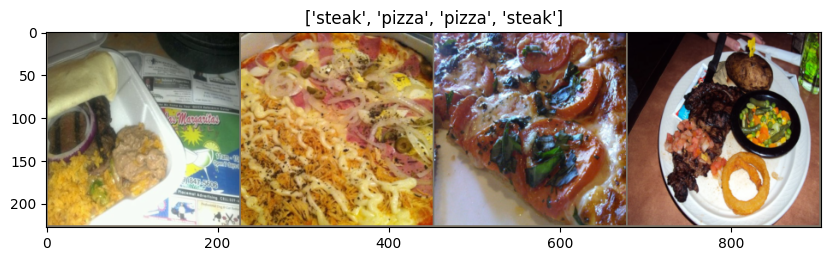

In [ ]:
# 1. Define data transformations
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Resize all images to 224x224
    transforms.ToTensor(),         # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # Normalize pixel values (ImageNet statistics)
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomHorizontalFlip(0.4)
])

# 2. Create datasets using ImageFolder
train_data = datasets.ImageFolder(root="train",
                                  transform=data_transforms) # Write your code here
test_data = datasets.ImageFolder(root="test",
                                  transform=data_transforms) # Write your code here

# Get class names and their mapping
class_names = train_data.classes
class_to_idx = train_data.class_to_idx

print(f"Class names: {class_names}")
print(f"Class to index mapping: {class_to_idx}")
print(f"Number of training samples: {len(train_data)}")
print(f"Number of testing samples: {len(test_data)}")

# 3. Create DataLoaders
BATCH_SIZE = 32 # You can experiment with different batch sizes

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=32,
                              shuffle=True) # Write your code here

test_dataloader = DataLoader(dataset=test_data,
                              batch_size=len(test_data),
                              shuffle=False) # Write your code here

print(f"Number of batches in training DataLoader: {len(train_dataloader)}")
print(f"Number of batches in testing DataLoader: {len(test_dataloader)}")

# Let's visualize a sample image and its label
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0)) # Convert from (C, H, W) to (H, W, C)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean # Undo normalization
    inp = np.clip(inp, 0, 1) # Clip pixel values to [0, 1]
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a batch of training data
inputs, classes = next(iter(train_dataloader))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs[:4]) # Show first 4 images

plt.figure(figsize=(10, 5))
imshow(out, title=[class_names[x] for x in classes[:4]])
plt.show()

## Part 1: Implement and Train LeNet

LeNet-5 is one of the earliest convolutional neural networks, developed by Yann LeCun et al. in the 1990s. While originally designed for smaller images (like MNIST digits), we will adapt its architecture for our 224x224 pixel images.

![lenet5](http://d2l.ai/_images/lenet.svg)

### LeNet Architecture (Adapted for 224x224 input, 3 output classes):

1.  **Input Layer**: 3x224x224 image (RGB channels).
2.  **Conv1**: ([Conv2d document](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html))
    *   Input Channels: 3
    *   Output Channels: 6
    *   Kernel Size: 5x5
    *   Stride: 1
    *   Activation: ReLU
3.  **Pool1**: ([MaxPool2d document](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html))
    *   Type: Max Pooling
    *   Kernel Size: 2x2
    *   Stride: 2
4.  **Conv2**:
    *   Input Channels: 6
    *   Output Channels: 16
    *   Kernel Size: 5x5
    *   Stride: 1
    *   Activation: ReLU
5.  **Pool2**:
    *   Type: Max Pooling
    *   Kernel Size: 2x2
    *   Stride: 2
6.  **Flatten**: Flatten the 3D feature maps into a 1D vector.
    *   *Hint*: After Pool2, the feature map size will be `16 * (something) * (something)`. You'll need to calculate this dimension based on the input size and the conv/pool operations.
        *   Input (224x224) -> Conv1 (224-5+1 = 220x220)
        *   Pool1 (220/2 = 110x110)
        *   Conv2 (110-5+1 = 106x106)
        *   Pool2 (106/2 = 53x53)
        *   So, the output of Pool2 will be `16 * 53 * 53`.
7.  **FC1 (Fully Connected 1)**:
    *   Input Features: `16 * 53 * 53`
    *   Output Features: 120
    *   Activation: ReLU
8.  **FC2 (Fully Connected 2)**:
    *   Input Features: 120
    *   Output Features: 84
    *   Activation: ReLU
9.  **Output Layer (FC3)**:
    *   Input Features: 84
    *   Output Features: 3 (for pizza, steak, sushi)

**Your Task:**
1.  Implement the `LeNet` class following the architecture above.
2.  Instantiate the model and move it to the `device` (GPU/CPU).
3.  Define the loss function (`nn.CrossEntropyLoss`) and optimizer (`optim.Adam`).
4.  Train the LeNet model for a few epochs (e.g., 5-10).
5.  Evaluate its performance on the test set.

In [ ]:
class LeNet(nn.Module):
    def __init__(self, num_classes=3):
        super(LeNet, self).__init__()
        # Write your code here
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5)
        self.act1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.act2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(16 * 53 * 53, 120) # Calculate input features based on image size and conv/pool operations
        self.act3 = nn.ReLU()
        self.fc2 = nn.Linear(120, 84)
        self.act4 = nn.ReLU()
        self.fc3 = nn.Linear(84, num_classes)


    def forward(self, x):
        # Write your code here
        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.act3(x)
        x = self.fc2(x)
        x = self.act4(x)
        x = self.fc3(x)

        return x

lenet_model = LeNet(num_classes=3)

In [ ]:
lenet_model

LeNet(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (act1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

In [ ]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lenet_model.parameters(), lr=0.001)

In [ ]:
# --- Your Code Below ---

# Training loop function (to be reused)
def train_model(model, train_dataloader, test_dataloader, criterion, optimizer, num_epochs):
    print(f"\n--- Training {model.__class__.__name__} for {num_epochs} epochs ---")
    results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in tqdm(range(num_epochs), desc="Training Progress"):
        # Training phase
        model.train() # Set model to training mode
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, labels in train_dataloader:
            # Write your code here
            # 1. Move inputs and labels to device
            x = inputs.to(device)
            y = labels.to(device)

            # 2. Zero the gradient
            optimizer.zero_grad()

            # 3. Make predictions
            y_pred = model(x)

            # 4. Calculate the loss
            loss = criterion(y_pred, y)

            # 5. Calculate the gradients
            loss.backward()

            # 6. Update model's parameters
            optimizer.step()

            # Calculate total loss and accuracy
            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(y_pred.data, 1) # Corrected to use y_pred
            train_total += labels.size(0)
            train_correct += (predicted == y).sum().item() # Corrected to use y

        epoch_train_loss = train_loss / len(train_dataloader.dataset)
        epoch_train_acc = train_correct / train_total
        results["train_loss"].append(epoch_train_loss)
        results["train_acc"].append(epoch_train_acc)

        # Evaluation phase
        model.eval() # Set model to evaluation mode
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        with torch.no_grad(): # Disable gradient calculation for evaluation
            for inputs, labels in test_dataloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()

        epoch_test_loss = test_loss / len(test_dataloader.dataset)
        epoch_test_acc = test_correct / test_total
        results["test_loss"].append(epoch_test_loss)
        results["test_acc"].append(epoch_test_acc)

        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
              f"Test Loss: {epoch_test_loss:.4f}, Test Acc: {epoch_test_acc:.4f}")
    return results

In [ ]:
# Instantiate LeNet model
lenet_model = LeNet(num_classes=len(class_names)).to(device)
optimizer = optim.Adam(lenet_model.parameters(), lr=0.001)
print(lenet_model)

LeNet(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1))
  (act1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)


In [ ]:
# Train the LeNet model
lenet_model.to(device) # Ensure the model is on the correct device
lenet_results = train_model(lenet_model, train_dataloader, test_dataloader, criterion, optimizer, num_epochs=10)


--- Training LeNet for 10 epochs ---


Training Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 - Train Loss: 1.0978, Train Acc: 0.3333 | Test Loss: 1.1013, Test Acc: 0.2800
Epoch 2/10 - Train Loss: 1.0977, Train Acc: 0.3289 | Test Loss: 1.1018, Test Acc: 0.2400
Epoch 3/10 - Train Loss: 1.0983, Train Acc: 0.3378 | Test Loss: 1.1006, Test Acc: 0.2667
Epoch 4/10 - Train Loss: 1.0981, Train Acc: 0.3244 | Test Loss: 1.1008, Test Acc: 0.2400
Epoch 5/10 - Train Loss: 1.0984, Train Acc: 0.3244 | Test Loss: 1.1001, Test Acc: 0.2800
Epoch 6/10 - Train Loss: 1.0977, Train Acc: 0.3467 | Test Loss: 1.1018, Test Acc: 0.2000
Epoch 7/10 - Train Loss: 1.0980, Train Acc: 0.3467 | Test Loss: 1.1024, Test Acc: 0.1867
Epoch 8/10 - Train Loss: 1.0978, Train Acc: 0.3378 | Test Loss: 1.1020, Test Acc: 0.2400
Epoch 9/10 - Train Loss: 1.0975, Train Acc: 0.3467 | Test Loss: 1.1013, Test Acc: 0.2400
Epoch 10/10 - Train Loss: 1.0985, Train Acc: 0.2933 | Test Loss: 1.1015, Test Acc: 0.2533


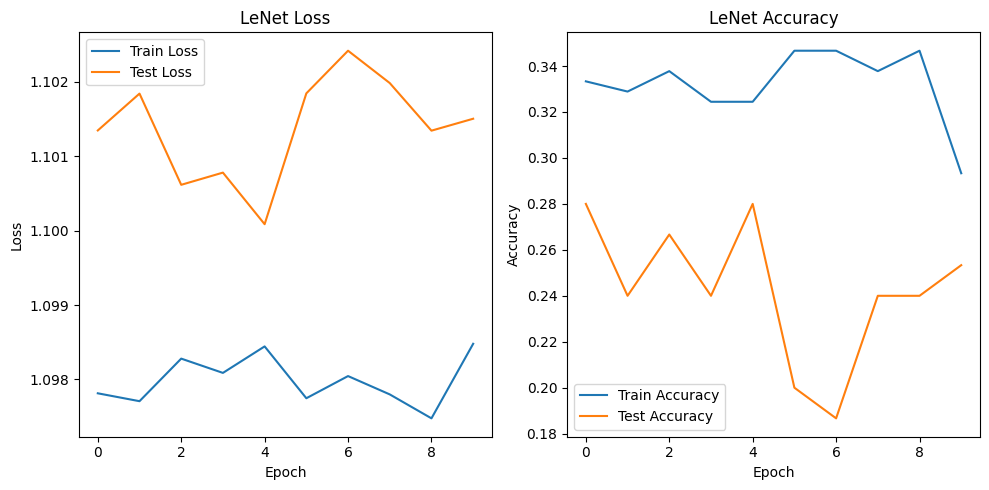

In [ ]:
# Plot training history
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(lenet_results['train_loss'], label='Train Loss')
plt.plot(lenet_results['test_loss'], label='Test Loss')
plt.title('LeNet Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(lenet_results['train_acc'], label='Train Accuracy')
plt.plot(lenet_results['test_acc'], label='Test Accuracy')
plt.title('LeNet Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

### Questions for Part 1:
1. How did the LeNet model perform on the test set? What was its final test accuracy?
   * **Your Answer:** จากผลการฝึก LeNet บน Test Set พบว่าโมเดลมีค่าความถูกต้อง (Test Accuracy) อยู่ที่ประมาณ 25.33% ซึ่งถือว่าค่อนข้างต่ำ โมเดลยังไม่สามารถจำแนกประเภทของรูปภาพได้ดีนัก

## Part 2: Transfer Learning

Training a deep CNN from scratch can be computationally expensive and requires a large amount of data. Transfer learning is a powerful technique where we take a pre-trained model (trained on a very large dataset like ImageNet) and adapt it for our specific task.

Here, we will use `EfficientNet_B0` from `torchvision.models`, which is a powerful and efficient model.

[List of pretrained models in Pytorch](https://docs.pytorch.org/vision/main/models.html#classification)

**Your Task:**
1.  Load a pre-trained `EfficientNet_B0` model.
2.  "Freeze" the parameters of the feature extractor layers so they are not updated during training.
3.  Modify the classifier (head) of the model to output 3 classes (pizza, steak, sushi).
    *   *Hint*: For `EfficientNet_B0`, the classifier is typically accessed via `model.classifier`. You'll need to replace its last layer.
4.  Instantiate the modified model and move it to the `device`.
5.  Define the loss function (`nn.CrossEntropyLoss`) and optimizer.
    *   *Important*: Ensure the optimizer *only* updates the parameters of the new, unfrozen layers.
6.  Train the transfer learning model for a few epochs (e.g., 5-10).
7.  Evaluate its performance on the test set.

In [ ]:
# 1. Load a pre-trained EfficientNet_B0 model
efficientnet_model = models.efficientnet_b0(pretrained=True)
print("Original EfficientNet_B0 classifier head:")
print(efficientnet_model.classifier)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 152MB/s]

Original EfficientNet_B0 classifier head:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [ ]:
efficientnet_model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
efficientnet_model.classifier[1]

Linear(in_features=1280, out_features=1000, bias=True)

In [ ]:
# 2. Freeze all parameters in the feature extractor part
#### Write your code here
for param in efficientnet_model.features.parameters():
  param.requires_grad = False

# 3. Modify the classifier head for 3 classes
# EfficientNet's classifier is a sequential block, typically with a dropout and a linear layer.
# We need to replace the last linear layer.
# 3.1 Get input features to the last linear layer


# 3.2 Change the head (the classifier) of the model
#     Use nn.Sequential() to create a small model with a sequence of layers
efficientnet_model.classifier[1] = nn.Linear(1280, 3)

efficientnet_model = efficientnet_model.to(device)
print("\nModified EfficientNet_B0 classifier head:")
print(efficientnet_model.classifier)


Modified EfficientNet_B0 classifier head:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=3, bias=True)
)


In [ ]:
# Check which parameters are being trained
print("\nParameters to be trained:")
params_to_update = []
for name, param in efficientnet_model.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print(name)


Parameters to be trained:
classifier.1.weight
classifier.1.bias


In [ ]:
# 4. Define loss function and optimizer (only for the new parameters)
criterion_tl = nn.CrossEntropyLoss() # Write your code here
optimizer_tl = optim.Adam(efficientnet_model.classifier.parameters(), lr=0.001) # Write your code here

In [ ]:
# 5. Train the transfer learning model
efficientnet_results = train_model(efficientnet_model, train_dataloader, test_dataloader, criterion_tl, optimizer_tl, num_epochs=10)


--- Training EfficientNet for 10 epochs ---


Training Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 - Train Loss: 1.1027, Train Acc: 0.3689 | Test Loss: 0.9322, Test Acc: 0.6000
Epoch 2/10 - Train Loss: 0.8984, Train Acc: 0.6489 | Test Loss: 0.7612, Test Acc: 0.8267
Epoch 3/10 - Train Loss: 0.7652, Train Acc: 0.8267 | Test Loss: 0.7031, Test Acc: 0.8667
Epoch 4/10 - Train Loss: 0.6733, Train Acc: 0.8667 | Test Loss: 0.6862, Test Acc: 0.8400
Epoch 5/10 - Train Loss: 0.6133, Train Acc: 0.8178 | Test Loss: 0.6477, Test Acc: 0.8267
Epoch 6/10 - Train Loss: 0.5475, Train Acc: 0.8578 | Test Loss: 0.5436, Test Acc: 0.8800
Epoch 7/10 - Train Loss: 0.5181, Train Acc: 0.8844 | Test Loss: 0.5034, Test Acc: 0.8933
Epoch 8/10 - Train Loss: 0.4679, Train Acc: 0.9022 | Test Loss: 0.4929, Test Acc: 0.8800
Epoch 9/10 - Train Loss: 0.4510, Train Acc: 0.8711 | Test Loss: 0.4436, Test Acc: 0.8800
Epoch 10/10 - Train Loss: 0.4118, Train Acc: 0.9200 | Test Loss: 0.4478, Test Acc: 0.9200


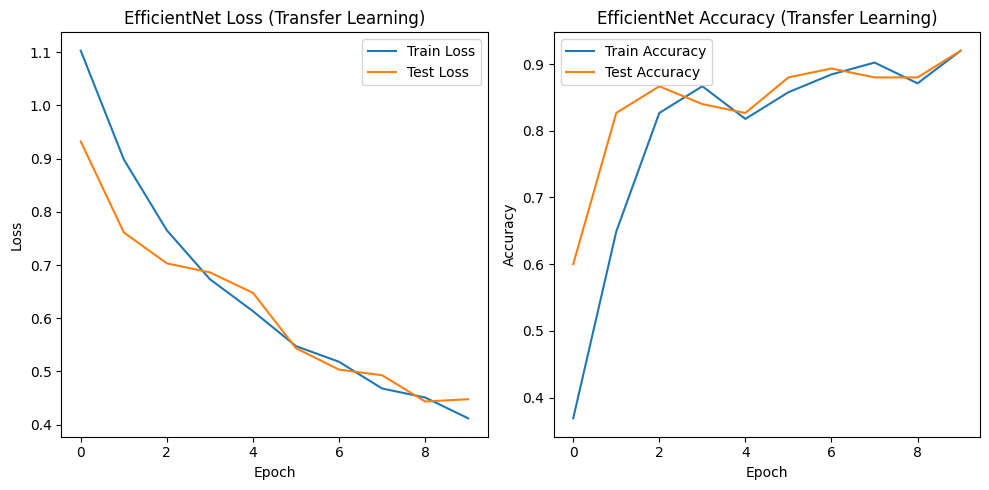

In [ ]:
# Plot training history
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(efficientnet_results['train_loss'], label='Train Loss')
plt.plot(efficientnet_results['test_loss'], label='Test Loss')
plt.title('EfficientNet Loss (Transfer Learning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(efficientnet_results['train_acc'], label='Train Accuracy')
plt.plot(efficientnet_results['test_acc'], label='Test Accuracy')
plt.title('EfficientNet Accuracy (Transfer Learning)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

### Questions for Part 2:
1. Compare the performance of the LeNet model (from Part 1) with the transfer learning model (EfficientNet_B0). Which one performed better and why do you think that is?
   * **Your Answer:** จากผลการทดลองพบว่าโมเดล Transfer Learning ที่ใช้ EfficientNet\_B0 มีประสิทธิภาพที่ดีกว่าโมเดล LeNet อย่างชัดเจน โดยมีค่าความถูกต้อง (Test Accuracy) สูงกว่ามาก (ประมาณ 92% เทียบกับ 25.33% ของ LeNet) เหตุผลหลักคือ EfficientNet\_B0 เป็นโมเดลที่มีขนาดใหญ่และซับซ้อนกว่า LeNet มาก และได้รับการฝึกฝนมาแล้วด้วยชุดข้อมูลขนาดใหญ่ (ImageNet) ทำให้มีคุณสมบัติ (features) ที่ดีในการแยกแยะรูปภาพ การนำคุณสมบัติเหล่านี้มาใช้กับชุดข้อมูลขนาดเล็กของเราจึงให้ผลลัพธ์ที่ดีกว่าการฝึกโมเดลขนาดเล็กอย่าง LeNet ตั้งแต่เริ่มต้นครับ
2. Explain the concept of "freezing" layers in transfer learning. Why is it done, and what are its benefits?
   * **Your Answer:** การ "Freezing" Layers ใน Transfer Learning คือการทำให้ Parameters (Weights และ Biases) ของ Layer บางส่วนในโมเดลที่ถูก Pre-trained มาแล้ว ไม่ได้รับการอัปเดตในระหว่างการฝึกฝนกับชุดข้อมูลใหม่ที่เราต้องการใช้งาน โดยปกติแล้ว เราจะ Freezing ส่วนของ Feature Extractor (Layer แรกๆ ที่เรียนรู้คุณสมบัติพื้นฐานของรูปภาพ เช่น ขอบ มุม ลวดลาย) และจะอนุญาตให้เฉพาะส่วนของ Classifier (Layer ท้ายๆ ที่ทำหน้าที่จำแนกประเภท) ได้รับการฝึกฝนใหม่ด้วยข้อมูลของเรา
     * **ทำไมถึงทำ?** เพื่อใช้ประโยชน์จากคุณสมบัติที่โมเดลได้เรียนรู้จากชุดข้อมูลขนาดใหญ่มาแล้ว และป้องกันไม่ให้ Parameters ที่เรียนรู้มาอย่างดีนั้นถูกทำลายด้วยการฝึกบนชุดข้อมูลขนาดเล็กของเรา นอกจากนี้ยังช่วยลดจำนวน Parameters ที่ต้องฝึก ทำให้ใช้ทรัพยากรในการฝึกน้อยลงและฝึกได้เร็วขึ้น
     * **ประโยชน์:** ช่วยให้โมเดลมีประสิทธิภาพที่ดีขึ้นบนชุดข้อมูลขนาดเล็กที่เรามี โดยไม่จำเป็นต้องมีข้อมูลจำนวนมากเท่ากับการฝึกโมเดลขนาดใหญ่ตั้งแต่เริ่มต้น ลดเวลาและทรัพยากรในการฝึก และช่วยให้โมเดลมี Generalization ที่ดีขึ้น
3. What challenges might arise when using transfer learning on a dataset that is significantly different from the dataset the pre-trained model was originally trained on (e.g., medical images vs. ImageNet)?
   * **Your Answer:** ความท้าทายหลักคือ ความแตกต่างของคุณสมบัติ (Feature Discrepancy) ระหว่างชุดข้อมูลที่ใช้ Pre-train (เช่น ImageNet ที่เป็นรูปภาพทั่วไป) กับชุดข้อมูลใหม่ที่เราต้องการใช้ (เช่น รูปภาพทางการแพทย์) คุณสมบัติที่โมเดลเรียนรู้จาก ImageNet อาจไม่เหมาะสมหรือไม่เพียงพอที่จะใช้แยกแยะความแตกต่างที่สำคัญในรูปภาพทางการแพทย์ซึ่งมีลักษณะเฉพาะ ความท้าทายอื่นๆ อาจรวมถึง:
     * **ความจำเป็นในการ Fine-tuning:** หากชุดข้อมูลใหม่แตกต่างจากเดิมมาก อาจต้องทำการ "Fine-tuning" เพิ่มเติม โดยการ Unfreeze Layer บางส่วนของ Feature Extractor และฝึกฝน Parameters เหล่านั้นด้วย Learning Rate ที่ต่ำๆ เพื่อปรับคุณสมบัติให้เข้ากับข้อมูลใหม่
     * **ขนาดของชุดข้อมูลใหม่:** แม้จะทำ Transfer Learning แต่ถ้าชุดข้อมูลใหม่มีขนาดเล็กมาก การปรับแก้ Classifier เพียงอย่างเดียวอาจยังไม่เพียงพอ หรือการ Fine-tuning อาจทำให้เกิด Overfitting ได้
     * **ประเภทของปัญหา:** Transfer Learning มักได้ผลดีกับงานประเภทเดียวกัน (เช่น Classification รูปภาพ) แต่ถ้าเปลี่ยนไปเป็นงานอื่น (เช่น Segmentation) อาจต้องมีการปรับเปลี่ยนสถาปัตยกรรมและวิธีการเพิ่มเติม

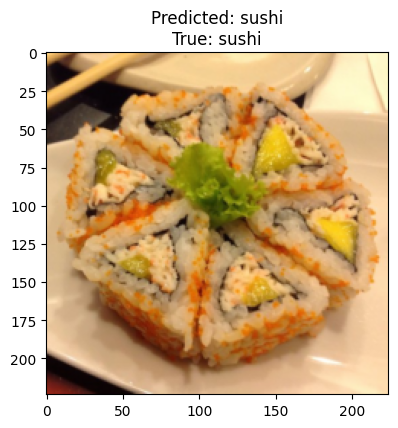

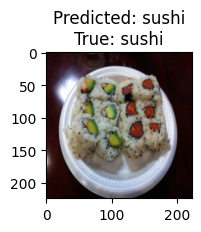

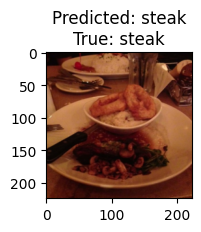

<Figure size 640x480 with 0 Axes>

In [ ]:
# 4. Choose 3 images from the test set. Display the images and show their predicted classes.
# Get some random indices from the test set
import random
num_images_to_show = 3
random_indices = random.sample(range(len(test_data)), num_images_to_show)

# Set model to evaluation mode and move to device
efficientnet_model.eval()
efficientnet_model.to(device)

# Get class names
class_names = test_data.classes

plt.figure(figsize=(15, 5))

with torch.no_grad():
    for i, idx in enumerate(random_indices):
        image, label = test_data[idx]

        # Add batch dimension and move to device
        image = image.unsqueeze(0).to(device)

        # Make prediction
        outputs = efficientnet_model(image)
        _, predicted_idx = torch.max(outputs.data, 1)
        predicted_class = class_names[predicted_idx.item()]
        true_class = class_names[label]

        # Display image and prediction
        plt.subplot(1, num_images_to_show, i + 1)
        imshow(image.cpu().squeeze(0), title=f"Predicted: {predicted_class}\nTrue: {true_class}")

plt.tight_layout()
plt.show()

In [ ]:
# Example of making prediction on an image

x = torch.rand(1, 3, 224, 224)  # an image

prediction = efficientnet_model(x.to(device))

torch.argmax(prediction)

tensor(1, device='cuda:0')